In [125]:
import pandas as pd
import plotnine as pn
import numpy as np

In [126]:
ranges_todd = [(0,19),
(20,21),
(22,24),
(25,26),
(27,30),
(31,34),
(35,39),
(40,44),
(45,49),
(50,90)]

In [127]:
def range_of_age(n,ranges):
    for i,r in enumerate(ranges):
        if n >= r[0] and n <= r[1]:
            return i

In [128]:
data_resnet_path = "/home/manza/paper_TFG/Age_estimation_from_3D_models/paper_execution/resnet_panorama/age_prediction_230116_model_rgb_resnet.csv"
data_resnet = pd.read_csv(data_resnet_path)
data_resnet = data_resnet[["TRUE", "COMBINED OUTPUT"]]
data_resnet["NETWORK"] = "ResNet-CNN"
data_resnet

,TRUE,COMBINED OUTPUT,NETWORK
0,16.0,17.563446,ResNet-CNN
1,16.0,17.420393,ResNet-CNN
2,17.0,20.915503,ResNet-CNN
3,17.0,23.860088,ResNet-CNN
4,18.0,17.841810,ResNet-CNN
...,...,...,...
87,56.0,55.621857,ResNet-CNN
88,56.0,46.047592,ResNet-CNN
89,56.0,31.524166,ResNet-CNN
90,61.0,53.888130,ResNet-CNN


In [129]:
data_panorama_path = "/home/manza/paper_TFG/Age_estimation_from_3D_models/paper_execution/resnet_panorama/age_prediction_221829_model_rgb_panoramacnn.csv"
data_panorama = pd.read_csv(data_panorama_path) 
data_panorama = data_panorama[["TRUE", "COMBINED OUTPUT"]]
data_panorama["NETWORK"] = "Panorama-CNN"
data_panorama

,TRUE,COMBINED OUTPUT,NETWORK
0,16.0,19.342804,Panorama-CNN
1,16.0,19.497171,Panorama-CNN
2,17.0,19.436728,Panorama-CNN
3,17.0,22.873266,Panorama-CNN
4,18.0,33.697693,Panorama-CNN
...,...,...,...
87,56.0,35.636760,Panorama-CNN
88,56.0,39.548786,Panorama-CNN
89,56.0,35.320550,Panorama-CNN
90,61.0,54.175293,Panorama-CNN


In [130]:
data = pd.concat([data_resnet, data_panorama])
data.columns = ["Age", "prediction", "network"]
# data["Age"] = data["Age"].astype(str)
data["Phase"] = [ range_of_age(x, ranges_todd) for x in data["Age"].to_list() ]
data["Phase"] = ["Phase {}".format(x+1) for x in data["Phase"].to_list()]
# data["Phase"] = pd.Categorical(data["Phase"], categories=["Phase {}".format(x+1) for x in data["Phase"].to_list()], ordered=True)
data

,Age,prediction,network,Phase
0,16.0,17.563446,ResNet-CNN,Phase 1
1,16.0,17.420393,ResNet-CNN,Phase 1
2,17.0,20.915503,ResNet-CNN,Phase 1
3,17.0,23.860088,ResNet-CNN,Phase 1
4,18.0,17.841810,ResNet-CNN,Phase 1
...,...,...,...,...
87,56.0,35.636760,Panorama-CNN,Phase 10
88,56.0,39.548786,Panorama-CNN,Phase 10
89,56.0,35.320550,Panorama-CNN,Phase 10
90,61.0,54.175293,Panorama-CNN,Phase 10


In [131]:
def generate_plot(data,name, group_by="Age"):
    # age_mean=np.mean(data['Age'])
    plot = pn.ggplot(data, pn.aes(x='Age', y='prediction', group=group_by, fill="Phase"))
    # + pn.geom_hline(yintercept=age_mean, color='black', linetype='dashed')
    plot += pn.geom_boxplot()#show_legend = False)#color='steelblue', fill='lightblue')
    plot += pn.labs(x='Age-at-death', y='Predicted Age', title=name, fill="")
    plot += pn.geom_segment(pn.aes(x=min(data['Age']), y=min(data['Age']), xend=max(data['Age']), yend=max(data['Age'])),
                    linetype='dotted', color='black')
    plot += pn.coord_cartesian(xlim=(min(data['Age']), max(data['Age'])), ylim=(min(data['Age']), max(data['Age'])))
    plot += pn.facet_wrap("~ network", ncol=1)
    plot += pn.theme(figure_size = (6, 6), dpi = 250, text=pn.element_text(family=['Arial'], size=14))
    plot += pn.scale_fill_discrete(limits = ["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Phase 5", "Phase 6", "Phase 7", "Phase 8", "Phase 9", "Phase 10"])
    return plot


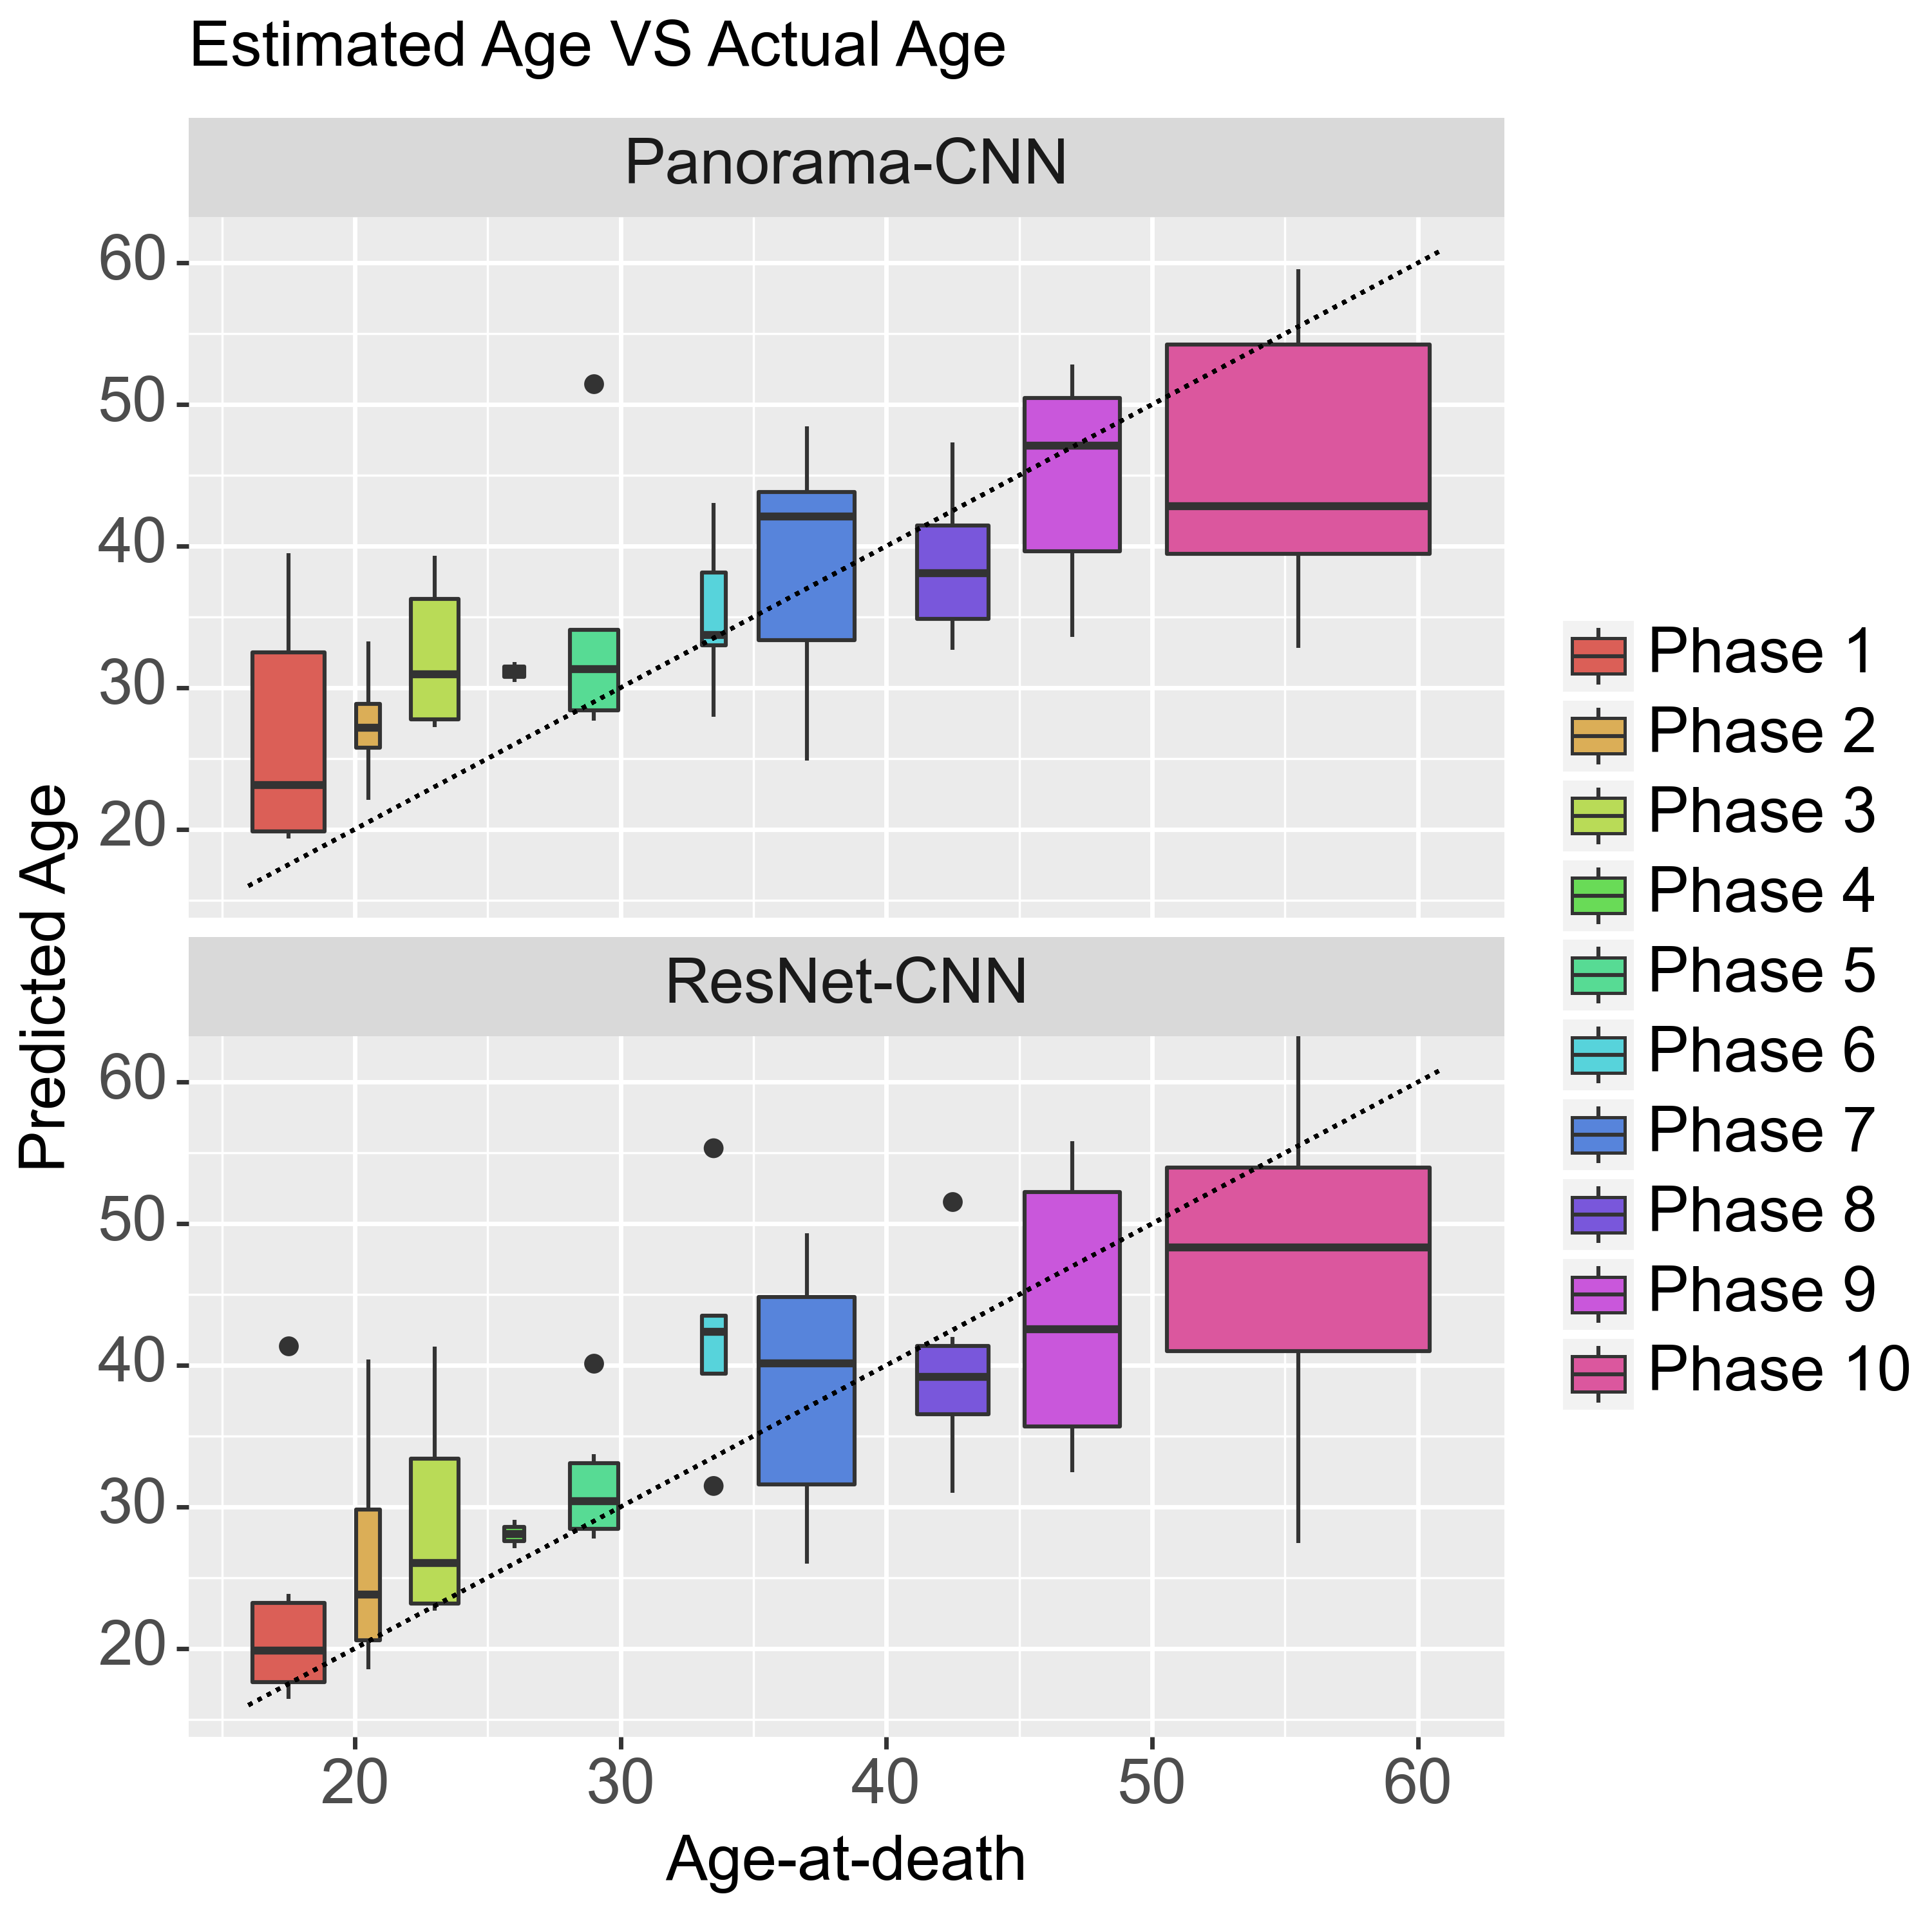

/home/manza/python-envs/tfg_env/lib/python3.8/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 6 in image.
/home/manza/python-envs/tfg_env/lib/python3.8/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /home/manza/paper_TFG/IEEE TMI-Age-at-death estimation from 3D models of the symphysis pubis by using a deep multi-view learning approach/actual_age_vs_predicted_age_by_todd_phase.png


In [132]:
plot = generate_plot(data, "Estimated Age VS Actual Age", "Phase")
print(plot)

plot.save("/home/manza/paper_TFG/IEEE TMI-Age-at-death estimation from 3D models of the symphysis pubis by using a deep multi-view learning approach/actual_age_vs_predicted_age_by_todd_phase.png")

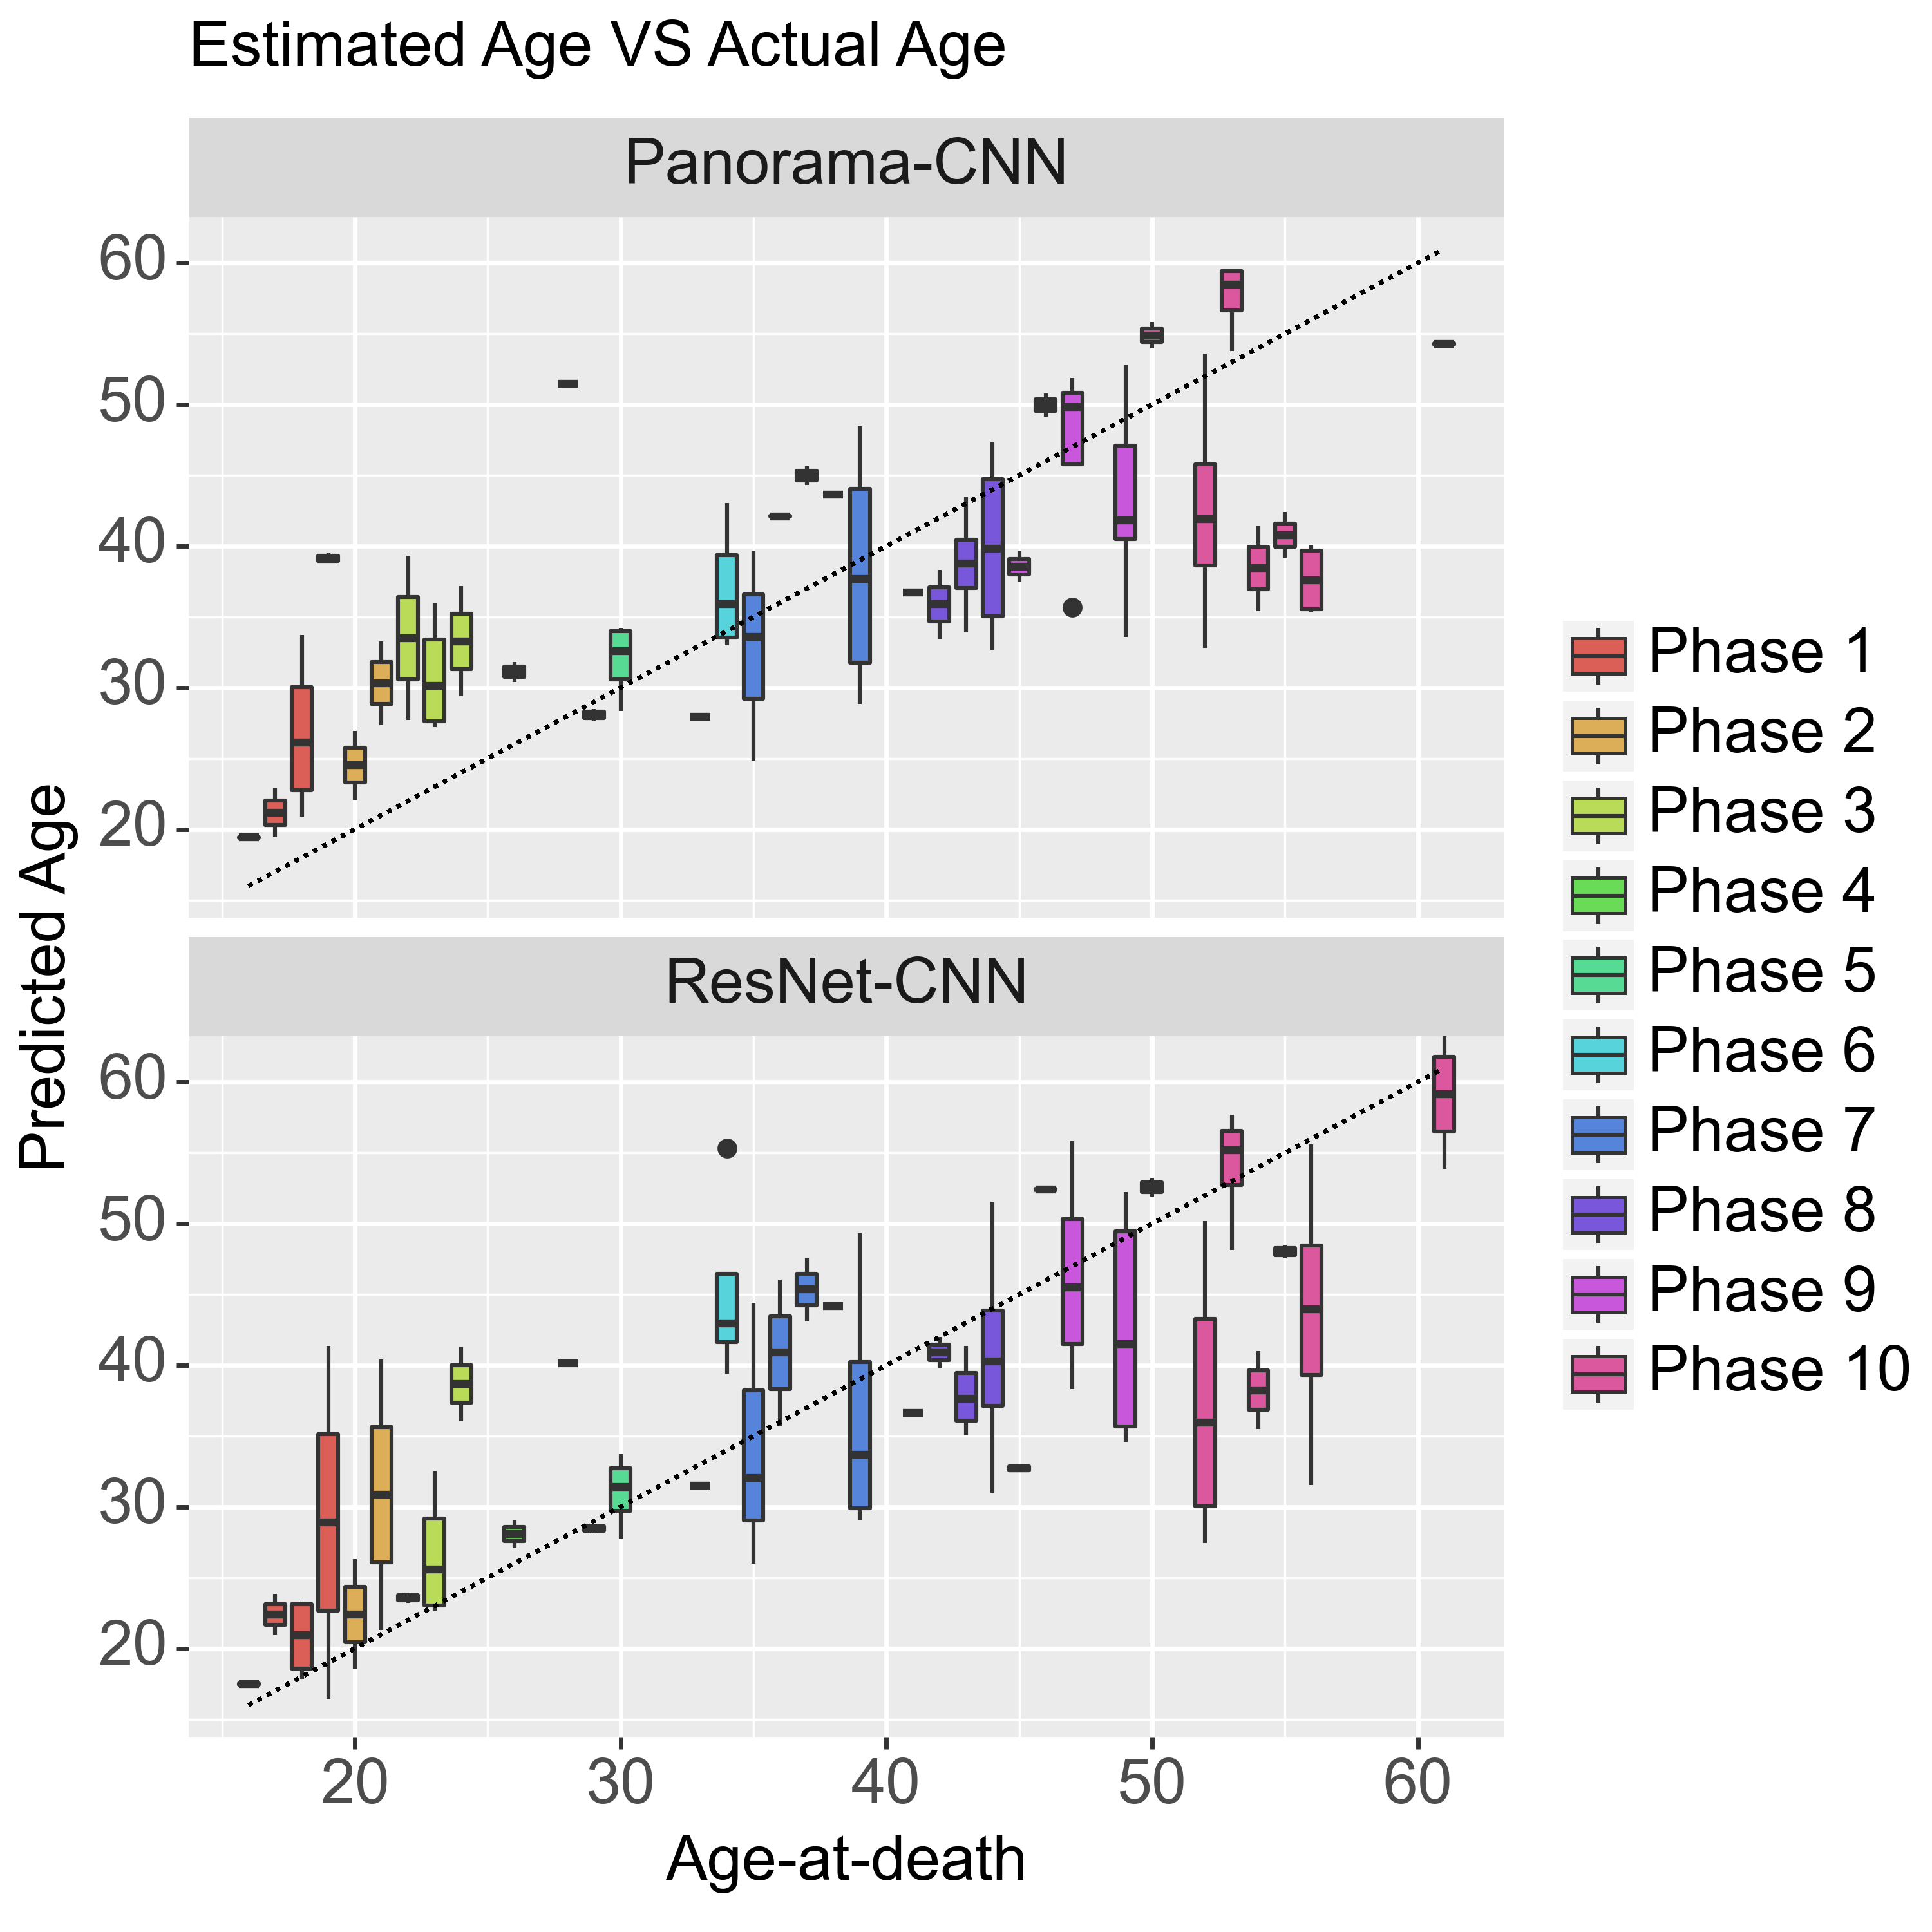

/home/manza/python-envs/tfg_env/lib/python3.8/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 6 in image.
/home/manza/python-envs/tfg_env/lib/python3.8/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /home/manza/paper_TFG/IEEE TMI-Age-at-death estimation from 3D models of the symphysis pubis by using a deep multi-view learning approach/actual_age_vs_predicted_age.png


In [133]:
plot = generate_plot(data, "Estimated Age VS Actual Age")
print(plot)

plot.save("/home/manza/paper_TFG/IEEE TMI-Age-at-death estimation from 3D models of the symphysis pubis by using a deep multi-view learning approach/actual_age_vs_predicted_age.png")